In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from tqdm import tqdm
import time
import os

In [3]:
# ==========================================
# 0. 하이퍼파라미터 및 경로 설정
# ==========================================
EPOCHS = 5
BATCH_SIZE = 8               # IMAGE_SIZE를 키웠으므로 메모리 안정을 위해 64 권장
LEARNING_RATE = 0.001         # 미세조정에 적합하도록 약간 낮춤
IMAGE_SIZE = 224              # 🌟 ResNet18 ImageNet 가중치 표준 입력 크기
NUM_WORKERS = 2
PIN_MEMORY = True

In [4]:
# 경로 설정
DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/ResNet18/dataset'
MODEL_SAVE_DIR = '/content/drive/MyDrive/Colab Notebooks/ResNet18'
MODEL_SAVE_PATH = f'{MODEL_SAVE_DIR}/resnet18_imagenet_best.pth'

# 저장 폴더 자동 생성
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print(DEVICE)

cuda


In [5]:
# ==========================================
# 1. 데이터 전처리 및 로드 (ImageFolder 사용)
# ==========================================
# 🌟 ImageNet 데이터셋의 색상 평균/표준편차 규격 적용
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("데이터셋을 불러오는 중...")
full_dataset = torchvision.datasets.ImageFolder(root=DATA_PATH, transform=transform)

class_names = full_dataset.classes
num_classes = len(class_names)
print(f"📁 총 데이터 수: {len(full_dataset)}개")
print(f"🏷️ 인식된 클래스 {num_classes}개: {class_names}\n")

train_size = int(0.8 * len(full_dataset))
val_size = int(0.1 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    full_dataset, [train_size, val_size, test_size]
)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
full_train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

데이터셋을 불러오는 중...
📁 총 데이터 수: 800개
🏷️ 인식된 클래스 8개: ['HEE', 'HJ', 'JK', 'JY', 'jh', 'js', 'ny', 'yj']



In [6]:
# ==========================================
# 2. 모델 구성 (ResNet18 + ImageNet)
# ==========================================
# 🌟 공식 ImageNet 가중치 로드
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# 사전 학습된 뼈대 가중치 동결 (특징 추출기 고정)
for param in model.parameters():
    param.requires_grad = False

# 최종 분류기(fc) 레이어 교체 (분류할 인물 수에 맞게 자동 세팅)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)

model = model.to(DEVICE)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 167MB/s]


In [7]:
# ==========================================
# 3. 훈련 및 평가 설정
# ==========================================
criterion = nn.CrossEntropyLoss()
# 새로 교체한 fc 레이어만 학습
optimizer = optim.Adam(model.fc.parameters(), lr=LEARNING_RATE)

best_val_loss = float('inf')
history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

print("🚀 학습을 시작합니다...\n")

# ==========================================
# 4. 훈련 루프
# ==========================================
for epoch in range(EPOCHS):
    start_time = time.time()

    # [Train Phase]
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]", leave=False)

    for inputs, labels in train_loop:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        train_loop.set_postfix(loss=(running_loss/total))

    epoch_loss = running_loss / train_size
    epoch_acc = correct / total
    history['loss'].append(epoch_loss)
    history['accuracy'].append(epoch_acc)

    # [Validation Phase]
    model.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0
    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]", leave=False)

    with torch.no_grad():
        for inputs, labels in val_loop:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / val_size
    val_acc = val_correct / val_total
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_acc)

    epoch_duration = time.time() - start_time
    print(f"Epoch {epoch+1}/{EPOCHS} - {epoch_duration:.0f}s - loss: {epoch_loss:.4f} - accuracy: {epoch_acc:.4f} - val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}")

    # 🌟 최고 성능 모델 저장
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        # 가중치와 클래스 이름을 함께 딕셔너리로 묶어서 저장
        checkpoint = {
            'model_state': model.state_dict(),
            'classes': class_names
        }
        torch.save(checkpoint, MODEL_SAVE_PATH)

🚀 학습을 시작합니다...



Epoch 1/5 - 122s - loss: 1.1323 - accuracy: 0.7281 - val_loss: 0.3571 - val_accuracy: 0.9750


Epoch 2/5 - 3s - loss: 0.3542 - accuracy: 0.9531 - val_loss: 0.2116 - val_accuracy: 0.9500


Epoch 3/5 - 3s - loss: 0.2166 - accuracy: 0.9703 - val_loss: 0.1696 - val_accuracy: 0.9500


Epoch 4/5 - 4s - loss: 0.1319 - accuracy: 0.9922 - val_loss: 0.0957 - val_accuracy: 0.9750


Epoch 5/5 - 3s - loss: 0.0988 - accuracy: 0.9891 - val_loss: 0.0738 - val_accuracy: 0.9875


In [8]:
# ==========================================
# 5. 최종 평가 및 Confusion Matrix
# ==========================================
print(f"\n🎯 최고 성능 모델({MODEL_SAVE_PATH})을 불러와 최종 평가를 진행합니다...")
checkpoint = torch.load(MODEL_SAVE_PATH)
model.load_state_dict(checkpoint['model_state'])
model.eval()

# 테스트 데이터 평가 함수
def evaluate_test_data(eval_model, dataloader):
    run_loss, corr, tot = 0.0, 0, 0
    with torch.no_grad():
        for inp, lbl in dataloader:
            inp, lbl = inp.to(DEVICE), lbl.to(DEVICE)
            out = eval_model(inp)
            run_loss += criterion(out, lbl).item() * inp.size(0)
            _, pred = torch.max(out, 1)
            tot += lbl.size(0)
            corr += (pred == lbl).sum().item()
    return run_loss / tot, corr / tot

test_loss, test_acc = evaluate_test_data(model, test_loader)
print(f"✔️ Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

# Confusion Matrix
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in full_train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

C = confusion_matrix(all_labels, all_preds)
print("\n[Confusion Matrix]\n", C)



🎯 최고 성능 모델(/content/drive/MyDrive/Colab Notebooks/ResNet18/resnet18_imagenet_best.pth)을 불러와 최종 평가를 진행합니다...
✔️ Test Loss: 0.0360, Test Accuracy: 1.0000

[Confusion Matrix]
 [[78  0  0  0  0  0  0  0]
 [ 0 77  0  0  0  1  0  0]
 [ 0  0 82  0  0  0  0  0]
 [ 0  0  0 78  0  0  0  0]
 [ 0  0  0  0 86  0  0  0]
 [ 1  0  0  0  0 79  0  0]
 [ 0  0  0  0  0  0 76  0]
 [ 0  0  0  0  0  0  0 82]]


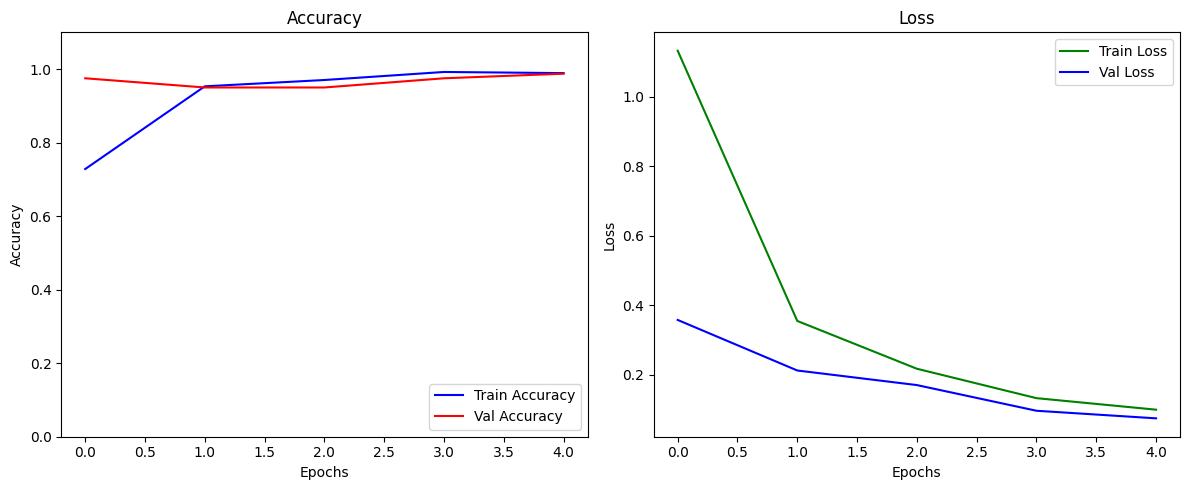

In [9]:
import matplotlib.pyplot as plt

# ==========================================
# 6. 학습 결과 시각화
# ==========================================
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plotting Accuracy (now at ax[0])
ax[0].set_ylim(0, 1.1)
ax[0].plot(history['accuracy'], "b-", label="Train Accuracy")
ax[0].plot(history['val_accuracy'], "r-", label="Val Accuracy")
ax[0].set_title("Accuracy")
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')
ax[0].legend(loc='lower right')

# Plotting Loss (now at ax[1])
ax[1].plot(history['loss'], "g-", label="Train Loss")
ax[1].plot(history['val_loss'], "b-", label="Val Loss") # Add val_loss
ax[1].set_title("Loss")
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].legend(loc='upper right') # Add legend for loss plot

fig.tight_layout()
plt.show()

In [10]:
fig.savefig(f'{MODEL_SAVE_DIR}/ImagesNet_ResNet18_training_history.png')
print(f"Training history plot saved to {MODEL_SAVE_DIR}/ImagesNet_ResNet18_training_history.png")

Training history plot saved to /content/drive/MyDrive/Colab Notebooks/ResNet18/ImagesNet_ResNet18_training_history.png



[Classification Report]
              precision    recall  f1-score   support

         HEE       0.99      1.00      0.99        78
          HJ       1.00      0.99      0.99        78
          JK       1.00      1.00      1.00        82
          JY       1.00      1.00      1.00        78
          jh       1.00      1.00      1.00        86
          js       0.99      0.99      0.99        80
          ny       1.00      1.00      1.00        76
          yj       1.00      1.00      1.00        82

    accuracy                           1.00       640
   macro avg       1.00      1.00      1.00       640
weighted avg       1.00      1.00      1.00       640



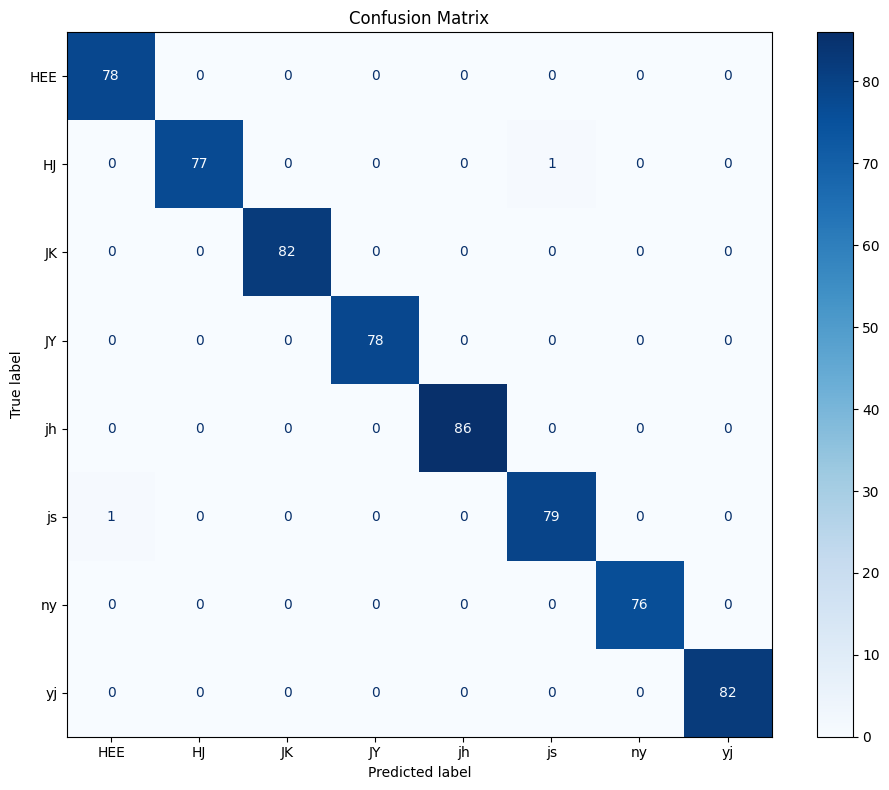

In [11]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Classification Report
print("\n[Classification Report]")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion Matrix Visualization
fig_cm, ax_cm = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    all_labels, all_preds, display_labels=class_names, cmap=plt.cm.Blues, ax=ax_cm
)
ax_cm.set_title('Confusion Matrix')
plt.xticks(rotation=0, ha='center') # Changed rotation to 0 for horizontal labels
plt.tight_layout()
plt.show()

# Save Confusion Matrix plot
fig_cm.savefig(f'{MODEL_SAVE_DIR}/ImagesNet_ResNet_confusion_matrix.png')
# print(f"Confusion matrix plot saved to {MODEL_SAVE_DIR}/confusion_matrix.png")